In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


## Raw data

In [ ]:
barra_file = '/g/data/xv83/dbi599/rba/Rx1day/BARRA-R2/rx1day_yr_BARRA-R2_aus-states-cities_1980-2024.csv'
df_barra = pd.read_csv(barra_file)

In [2]:
def plot_location(model, experiment, location, start_year=1950):
    """Scatterplot for a given location"""

    infile = f'/g/data/xv83/dbi599/rba/Rx1day/{model}/{experiment}/rx1day_yr_{model}_{experiment}_ensemble_aus-states-cities_1850-2100.csv'
    df = pd.read_csv(infile)
    fig, ax = plt.subplots(figsize=[15,7])
    sns.scatterplot(
        ax=ax,
        data=df[df['year'] >= start_year],
        x='year',
        y=location,
        hue='run',
    )
#    sns.scatterplot(
#        ax=ax,
#        data=df_barra,
#        x='year',
#        y=location,
#        color='black',
#        label='BARRA-R2',
#    )
    ax.set_ylabel('Rx1day')
    ax.set_title(f'{model} - {experiment} - {location}')
    ax.legend(bbox_to_anchor=(1.05, 1.0), ncol=2)
    ax.grid()
    plt.show()

In [3]:
def plot_dist(model, experiment, location, start_year=1950, end_year=2014):
    """Histogram for a given location"""

    infile = f'/g/data/xv83/dbi599/rba/Rx1day/{model}/{experiment}/rx1day_yr_{model}_{experiment}_ensemble_aus-states-cities_1850-2100.csv'
    df = pd.read_csv(infile)
    df_ref = df[(df['year'] >= start_year) & (df['year'] <= end_year)]
    fig, ax = plt.subplots()
    sns.histplot(
        ax=ax,
        data=df_ref,
        x=location,
    )
    ax.set_ylabel('Rx1day')
    ax.set_title(f'{model} - {experiment} - {location}')
    ax.grid()
    plt.show()

#### Individual models

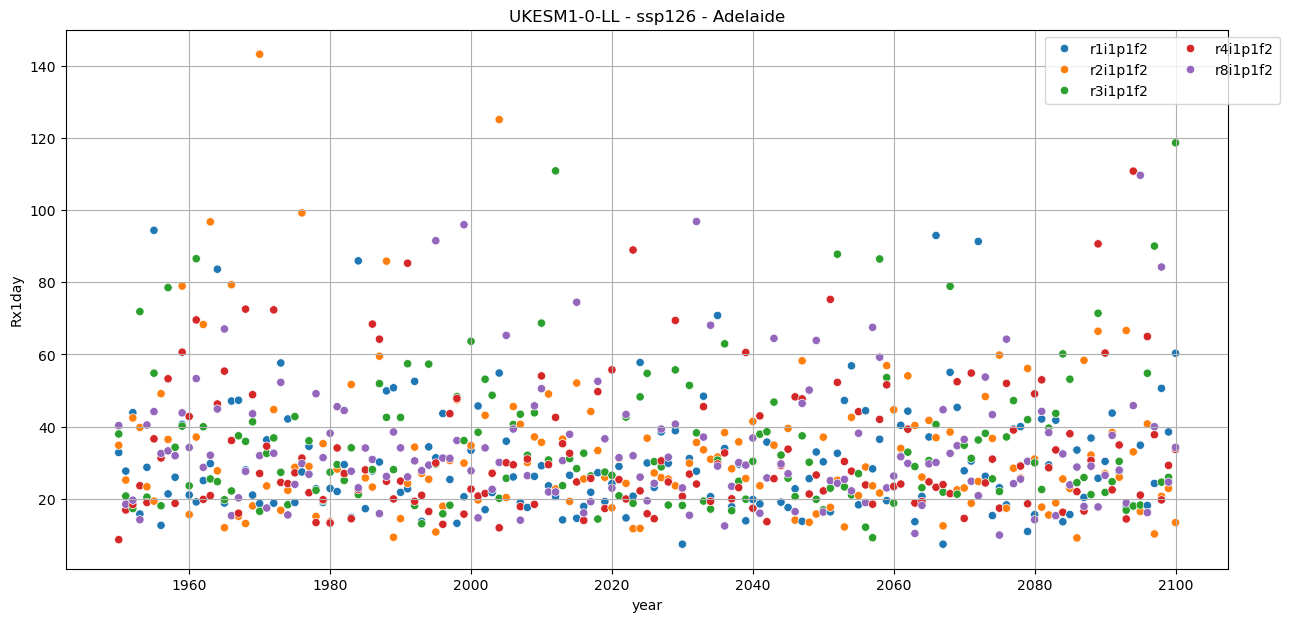

In [12]:
plot_location('UKESM1-0-LL', 'ssp126', 'Adelaide')

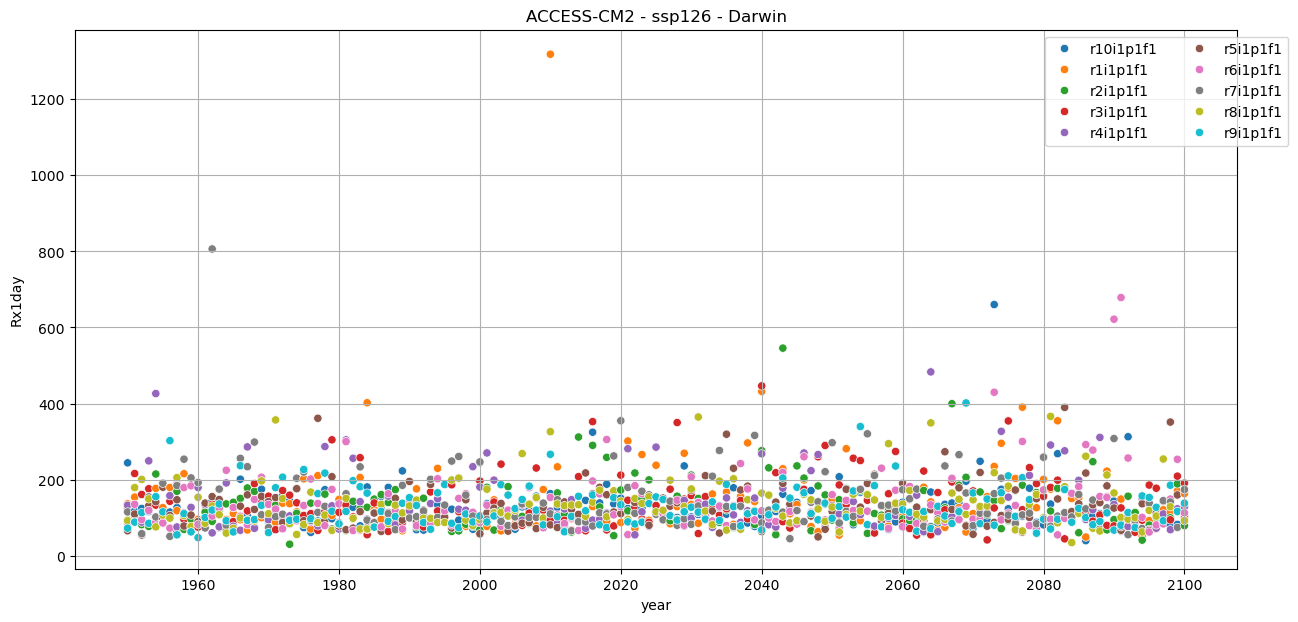

In [8]:
plot_location('ACCESS-CM2', 'ssp126', 'Darwin')

In [ ]:
for model in ['ACCESS-ESM1-5', 'ACCESS-CM2', 'CanESM5', 'IPSL-CM6A-LR', 'MPI-ESM1-2-LR', 'UKESM1-0-LL']:
    for exp in ['ssp126', 'ssp245', 'ssp370', 'ssp585']:
        plot_location(model, exp, 'AUS')

In [ ]:
plot_location('ACCESS-CM2', 'ssp245', 'VIC')

In [ ]:
plot_location('ACCESS-CM2', 'ssp245', 'Sydney')

In [ ]:
plot_dist('ACCESS-CM2', 'ssp370', 'AUS')

## Ensemble

In [6]:
colors = {
    'ACCESS-CM2': 'tab:blue',
    'ACCESS-ESM1-5': 'tab:green',
    'CanESM5': 'tab:orange',
    'EC-Earth3': 'tab:red',
    'MPI-ESM1-2-LR': 'tab:purple',
    'IPSL-CM6A-LR': 'tab:brown',
    'UKESM1-0-LL': 'tab:pink',
    'EC-Earth3-Veg': 'tab:gray',
}

linestyles = {
    'ssp585': 'solid',
    'ssp370': 'dashed',
    'ssp245': 'dashdot',
    'ssp126': 'dotted',
}

return_conversion = {
    '1-in-50 year': '98-0p',
    '1-in-40 year': '97-5p',
    '1-in-30 year': '96-7p',
    '1-in-20 year': '95-0p',
    '1-in-10 year': '90-0p',
}

def plot_ensemble_odds(
    models,
    experiments,
    location,
    return_period,
):
    """Ensemble odds of a year higher than a given return period for a given location."""

    # Plot
    fig, ax = plt.subplots()
    plabel = return_conversion[return_period]
    for model in models:
        for experiment in experiments:
            infile = f'/g/data/xv83/dbi599/rba/Rx1day/{model}/{experiment}/rx1day_yr_{plabel}-likelihood_{model}_{experiment}_aus-states-cities_1860-2091.csv'
            df = pd.read_csv(infile, header=7, index_col='year')
            df = df[location]
            sns.lineplot(
                ax=ax,
                data=df,
                label=f'{model} ({experiment})',
                color=colors[model],
                linestyle=linestyles[experiment],
            )
    ax.set_xlabel('year')
    ax.set_ylabel(f'odds of exceeding {return_period} event (%)') 
    ax.set_title(f'Rx1day - {location}')
    ax.legend(bbox_to_anchor=(1.05, 1), ncols=2, fontsize='small')
    ax.grid()
    plt.show()

    # Supporting info
    for model in models:
        pfile = f'/g/data/xv83/dbi599/rba/Rx1day/{model}/{experiments[0]}/rx1day_yr_percentiles_{model}_{experiments[0]}_aus-states-cities_1950-2014.csv' 
        pdf = pd.read_csv(pfile, header=6, index_col='percentile')
        pdf = pdf[location]
        p = float(plabel[0:-1].replace('-', '.'))
        pval = pdf.loc[p]
        print(f'{return_period} event, {model}: {pval}')
        
    obs = pd.read_csv(
        '/g/data/xv83/dbi599/rba/Rx1day/BARRA-R2/rx1day_yr_BARRA-R2_aus-states-cities_1980-2024.csv',
        index_col='year',
    )
    print('Top 10 years in BARRA-R2:')
    print(obs[location].sort_values(ascending=False)[0:15])

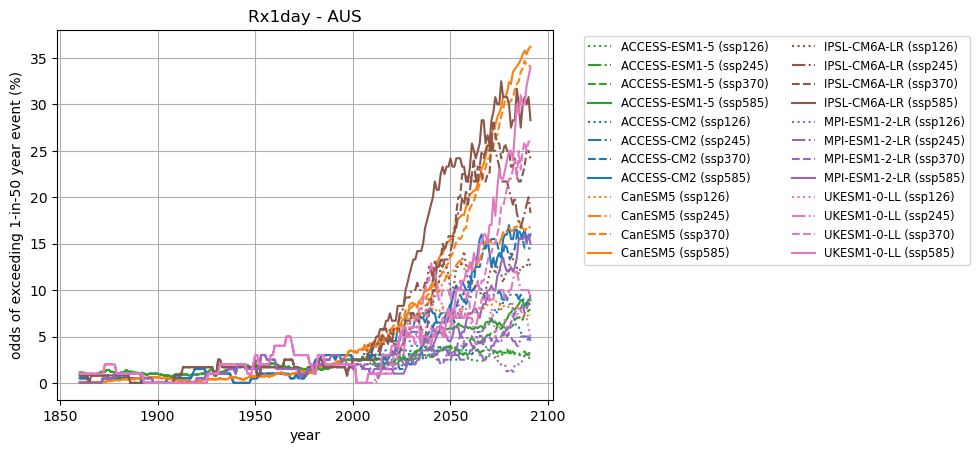

1-in-50 year event, ACCESS-ESM1-5: 76.08
1-in-50 year event, ACCESS-CM2: 78.65
1-in-50 year event, CanESM5: 76.97
1-in-50 year event, IPSL-CM6A-LR: 66.12
1-in-50 year event, MPI-ESM1-2-LR: 35.06
1-in-50 year event, UKESM1-0-LL: 75.56


FileNotFoundError: [Errno 2] No such file or directory: '/g/data/xv83/dbi599/rba/Rx1day/BARRA-R2/rx1day_yr_BARRA-R2_aus-states-cities_1980-2024.csv'

In [13]:
plot_ensemble_odds(
    ['ACCESS-ESM1-5', 'ACCESS-CM2', 'CanESM5', 'IPSL-CM6A-LR', 'MPI-ESM1-2-LR', 'UKESM1-0-LL'],
    ['ssp126', 'ssp245', 'ssp370', 'ssp585'],
    'AUS',
    '1-in-50 year',
)

In [ ]:
plot_ensemble_odds(
    ['ACCESS-ESM1-5', 'ACCESS-CM2', 'CanESM5', 'IPSL-CM6A-LR', 'MPI-ESM1-2-LR', 'UKESM1-0-LL'],
    ['ssp126', 'ssp245', 'ssp370', 'ssp585'],
    'NSW',
    '1-in-50 year',
)

In [ ]:
plot_ensemble_odds(
    ['ACCESS-ESM1-5', 'ACCESS-CM2', 'CanESM5', 'IPSL-CM6A-LR', 'MPI-ESM1-2-LR', 'UKESM1-0-LL'],
    ['ssp126', 'ssp245', 'ssp370', 'ssp585'],
    'WA',
    '1-in-20 year',
)